# Host-side acceleration control for STEVAL-EDUKIT01

This notebook sends **signed acceleration commands (pps^2)** to `AccelerationController.ino`.
The MCU integrates acceleration to target velocity and applies the corresponding signed STEP rate to the L6474.

This mirrors the important relation in the EDUKIT `main.c` acceleration path:

`v[k+1] = v[k] + a[k] * Ts`

but the controller calculation itself stays in Python/Jupyter.


In [20]:
import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# control_comms.py lives one directory up, in Pendulum_control/, so it is not on
# the kernel's path by default. Walk up until we find it.
import sys

for _candidate in (Path.cwd(), *Path.cwd().parents):
    if (_candidate / "control_comms.py").exists():
        if str(_candidate) not in sys.path:
            sys.path.insert(0, str(_candidate))
        break
else:
    raise FileNotFoundError("control_comms.py not found at or above " + str(Path.cwd()))

from control_comms import ControlComms, StatusCode

SERIAL_PORT = 'COM10'   # change for your machine
BAUD_RATE = 500000

CMD_SET_HOME = 0
CMD_SET_ACCELERATION = 1
CMD_HARD_STOP = 2
CMD_QUERY = 3
CMD_RESET_SAFETY = 4
CMD_ZERO_VELOCITY = 5

# Observation layout returned by firmware
OBS_PENDULUM_DEG = 0
OBS_ROTOR_DEG = 1
OBS_MEASURED_PPS = 2
OBS_TARGET_PPS = 3
OBS_ACCEL_PPS2 = 4
OBS_L6474_STATUS = 5
OBS_HOST_AGE_MS = 6


In [21]:
ctrl = ControlComms(timeout=0.2)
print(ctrl.get_serial_list())
status = ctrl.connect(SERIAL_PORT, BAUD_RATE)
print('connect:', status)
assert status == StatusCode.OK

resp = ctrl.step(CMD_RESET_SAFETY, [0.0])
print('reset:', resp)
resp = ctrl.step(CMD_SET_HOME, [0.0])
print('home:', resp)


(('COM10', 'STMicroelectronics STLink Virtual COM Port(COM10)', 'USB VID:PID=0483:374B SER=066DFF544949878667192716 LOCATION=1-1:x.2'),)
connect: StatusCode.OK
reset: (0, 104728, False, (0.0, 0.0, 0.0, 0.0, 0.0, 65027.0, 0.0))
home: None


## 1. Open-loop acceleration test

Start with the pendulum hanging down or removed. The test below sends a piecewise acceleration profile and records all returned observations.
Keep the acceleration and duration conservative until direction and mechanics are verified.


In [22]:
CONTROL_HZ = 100.0
DT = 1.0 / CONTROL_HZ
MAX_TEST_S = 4.0

def accel_profile(t):
    if t < 0.8:
        return 2500.0
    if t < 1.6:
        return 0.0
    if t < 2.4:
        return -2500.0
    return 0.0

rows = []
t0 = time.perf_counter()
next_t = t0

try:
    while True:
        now = time.perf_counter()
        t = now - t0
        if t >= MAX_TEST_S:
            break

        a_cmd = float(accel_profile(t))
        response = ctrl.step(CMD_SET_ACCELERATION, [a_cmd])
        if response is None:
            print(f'No firmware response at t={t:.2f} s; stopping early.')
            break

        status, timestamp_ms, terminated, obs = response
        rows.append({
            'host_t_s': t,
            'mcu_timestamp_ms': timestamp_ms,
            'status': status,
            'terminated': terminated,
            'accel_cmd_pps2': a_cmd,
            'pendulum_deg': obs[OBS_PENDULUM_DEG],
            'rotor_deg': obs[OBS_ROTOR_DEG],
            'measured_pps': obs[OBS_MEASURED_PPS],
            'target_pps': obs[OBS_TARGET_PPS],
            'firmware_accel_pps2': obs[OBS_ACCEL_PPS2],
            'l6474_status': obs[OBS_L6474_STATUS],
            'host_command_age_ms': obs[OBS_HOST_AGE_MS],
        })

        if terminated:
            print('Firmware terminated/latching safety, stopping test')
            break

        next_t += DT
        sleep_s = next_t - time.perf_counter()
        if sleep_s > 0:
            time.sleep(sleep_s)
finally:
    try:
        ctrl.step(CMD_ZERO_VELOCITY, [0.0])
        ctrl.step(CMD_HARD_STOP, [0.0])
    except Exception as exc:
        print('Could not stop the motor cleanly:', exc)
    # Built inside finally so a mid-run failure still keeps the samples already
    # collected, and so the next cell always has a df to work with.
    df = pd.DataFrame(rows)

print(f'{len(df)} samples collected')
df.head()


No firmware response at t=0.02 s; stopping early.
2 samples collected


,host_t_s,mcu_timestamp_ms,status,terminated,accel_cmd_pps2,pendulum_deg,rotor_deg,measured_pps,target_pps,firmware_accel_pps2,l6474_status,host_command_age_ms
0,0.000696,106498,0,False,2500.0,0.0,0.0,0.0,0.000,2500.0,65027.0,0.0
1,0.010396,106508,0,False,2500.0,0.0,0.0,0.0,24.193,2500.0,65027.0,0.0


data\acceleration_open_loop_20260914_221208.csv


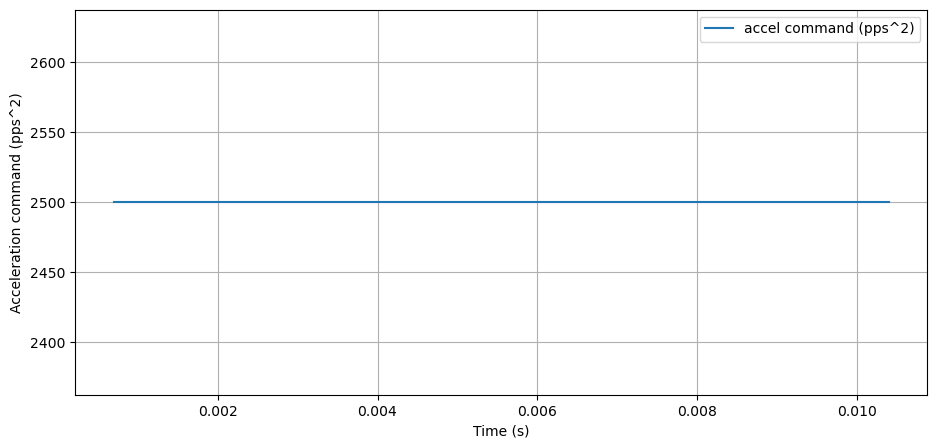

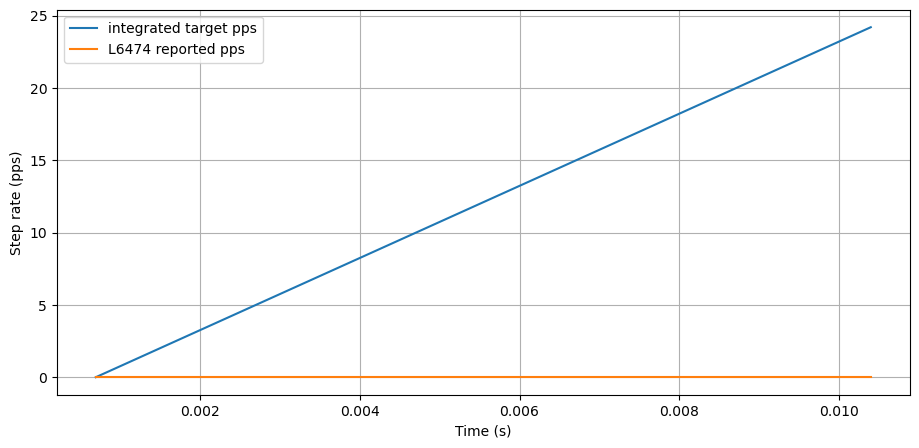

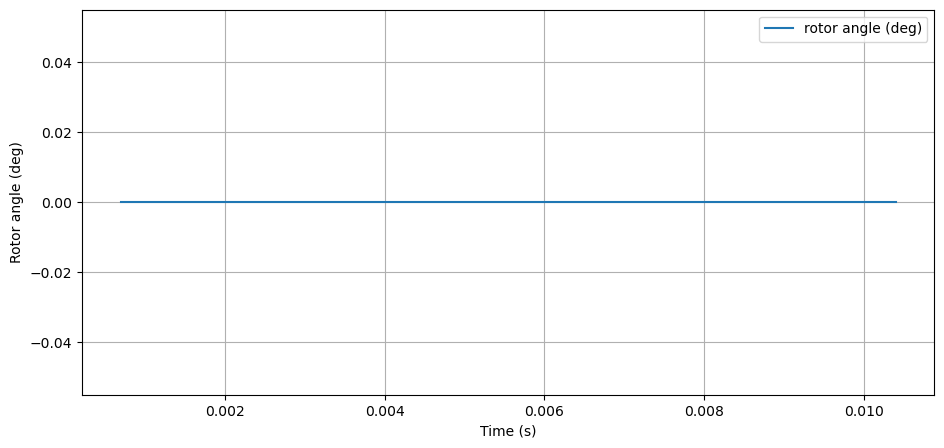

In [23]:
if len(df):
    Path('data').mkdir(exist_ok=True)
    stamp = time.strftime('%Y%m%d_%H%M%S')
    csv_path = Path('data') / f'acceleration_open_loop_{stamp}.csv'
    df.to_csv(csv_path, index=False)
    print(csv_path)

    plt.figure(figsize=(11, 5))
    plt.plot(df.host_t_s, df.accel_cmd_pps2, label='accel command (pps^2)')
    plt.xlabel('Time (s)')
    plt.ylabel('Acceleration command (pps^2)')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df.host_t_s, df.target_pps, label='integrated target pps')
    plt.plot(df.host_t_s, df.measured_pps, label='L6474 reported pps')
    plt.xlabel('Time (s)')
    plt.ylabel('Step rate (pps)')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df.host_t_s, df.rotor_deg, label='rotor angle (deg)')
    plt.xlabel('Time (s)')
    plt.ylabel('Rotor angle (deg)')
    plt.grid(True)
    plt.legend()
    plt.show()


## 2. Example host-side feedback controller

The controller below is intentionally a template. It computes acceleration in Jupyter from measured pendulum angle/velocity and rotor angle/velocity, then sends only the acceleration command to the MCU.

Do **not** assume these gains are stabilizing gains for your hardware. Verify sign first and tune conservatively.


In [24]:
SETPOINT_DEG = 180.0
CONTROL_HZ = 100.0
DT = 1.0 / CONTROL_HZ
MAX_ACCEL_CMD = 5000.0
PENDULUM_GUARD_DEG = 30.0
ROTOR_GUARD_DEG = 75.0
RUN_TIME_S = 8.0

# Example gains for acceleration output. Start very small.
KP_THETA = 40.0
KD_THETA = 3.0
KP_ROTOR = 0.5
KD_ROTOR = 0.05
CONTROL_SIGN = 1.0

def wrap_deg(x):
    return (x + 180.0) % 360.0 - 180.0

rows_fb = []
prev_t = None
prev_theta_err = None
prev_rotor = None
t0 = time.perf_counter()
next_t = t0

try:
    ctrl.step(CMD_RESET_SAFETY, [0.0])
    ctrl.step(CMD_ZERO_VELOCITY, [0.0])

    while True:
        host_now = time.perf_counter()
        elapsed = host_now - t0
        if elapsed >= RUN_TIME_S:
            break

        q = ctrl.step(CMD_QUERY, [0.0])
        if q is None:
            print(f'No query response at t={elapsed:.2f} s; stopping early.')
            break
        status, timestamp_ms, terminated, obs = q
        theta = obs[OBS_PENDULUM_DEG]
        rotor = obs[OBS_ROTOR_DEG]
        theta_err = wrap_deg(theta - SETPOINT_DEG)

        if prev_t is None:
            dt = DT
            theta_dot = 0.0
            rotor_dot = 0.0
        else:
            dt = max(1e-4, min(0.05, host_now - prev_t))
            theta_dot = (theta_err - prev_theta_err) / dt
            rotor_dot = (rotor - prev_rotor) / dt

        if abs(theta_err) > PENDULUM_GUARD_DEG or abs(rotor) > ROTOR_GUARD_DEG or terminated:
            print('Safety guard triggered')
            break

        # Acceleration-domain controller calculated entirely on the host.
        a_cmd = CONTROL_SIGN * (
            -KP_THETA * theta_err
            -KD_THETA * theta_dot
            -KP_ROTOR * rotor
            -KD_ROTOR * rotor_dot
        )
        a_cmd = float(np.clip(a_cmd, -MAX_ACCEL_CMD, MAX_ACCEL_CMD))

        r = ctrl.step(CMD_SET_ACCELERATION, [a_cmd])
        if r is None:
            print(f'No acceleration response at t={elapsed:.2f} s; stopping early.')
            break
        status, timestamp_ms, terminated, obs = r

        rows_fb.append({
            'host_t_s': elapsed,
            'pendulum_deg': obs[OBS_PENDULUM_DEG],
            'pendulum_error_deg': theta_err,
            'pendulum_rate_deg_s': theta_dot,
            'rotor_deg': obs[OBS_ROTOR_DEG],
            'rotor_rate_deg_s': rotor_dot,
            'accel_cmd_pps2': a_cmd,
            'target_pps': obs[OBS_TARGET_PPS],
            'measured_pps': obs[OBS_MEASURED_PPS],
            'status': status,
            'terminated': terminated,
        })

        prev_t = host_now
        prev_theta_err = theta_err
        prev_rotor = rotor

        next_t += DT
        sleep_s = next_t - time.perf_counter()
        if sleep_s > 0:
            time.sleep(sleep_s)
finally:
    try:
        ctrl.step(CMD_ZERO_VELOCITY, [0.0])
        ctrl.step(CMD_HARD_STOP, [0.0])
    except Exception as exc:
        print('Could not stop the motor cleanly:', exc)
    # Same reason as the open-loop cell: keep the data and always define df_fb.
    df_fb = pd.DataFrame(rows_fb)

print(f'{len(df_fb)} samples collected')
df_fb.tail()


Safety guard triggered
0 samples collected


""


In [25]:
if len(df_fb):
    Path('data').mkdir(exist_ok=True)
    stamp = time.strftime('%Y%m%d_%H%M%S')
    out = Path('data') / f'acceleration_feedback_{stamp}.csv'
    df_fb.to_csv(out, index=False)
    print(out)

    plt.figure(figsize=(11, 5))
    plt.plot(df_fb.host_t_s, df_fb.pendulum_error_deg, label='pendulum error (deg)')
    plt.plot(df_fb.host_t_s, df_fb.rotor_deg, label='rotor angle (deg)')
    plt.xlabel('Time (s)')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df_fb.host_t_s, df_fb.accel_cmd_pps2, label='accel command (pps^2)')
    plt.xlabel('Time (s)')
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(11, 5))
    plt.plot(df_fb.host_t_s, df_fb.target_pps, label='target pps')
    plt.plot(df_fb.host_t_s, df_fb.measured_pps, label='reported pps')
    plt.xlabel('Time (s)')
    plt.grid(True)
    plt.legend()
    plt.show()


In [26]:
# 펌웨어 업로드 후 재연결 — 보드가 리셋되어 기존 핸들은 죽어 있습니다.
try:
    ctrl.close()
except Exception:
    pass

ctrl = ControlComms(timeout=0.5)
assert ctrl.connect(SERIAL_PORT, BAUD_RATE) == StatusCode.OK, '포트를 다시 열 수 없음'
ctrl.ser.reset_input_buffer()      # 리셋 전에 남은 반쪽 줄 제거
ctrl.ser.reset_output_buffer()

ctrl.step(CMD_RESET_SAFETY, [0.0])  # 호스트 타임아웃 래치 해제

for attempt in range(5):
    r = ctrl.step(CMD_QUERY, [0.0])
    print(attempt, r)
    if r:
        n = len(r[3])
        print('observations =', n, '->',
              {2: 'ORIGINAL example', 4: 'PendulumController',
               7: 'AccelerationController (이 노트북이 기대하는 것)'}.get(n, 'unknown'))
        break
    time.sleep(0.1)
else:
    print('여전히 무응답 → 커널 재시작 후 셀 1-2부터 다시 실행')


0 None
1 None
2 (0, 179086, False, (0.0, 1.013, 0.0, 0.0, 0.0, 65042.0, 0.0))
observations = 7 -> AccelerationController (이 노트북이 기대하는 것)
